In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digitrecognition-ee708/sample_submission.csv
/kaggle/input/competitions/digitrecognition-ee708/train.csv
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_013107.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_017985.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_037638.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_035520.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_020499.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_033310.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_029992.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_005075.wav
/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/train_001574.wav
/kaggle/input/competitions/digitrecognition-ee708

In [3]:
# ============================================================
# IMPORTS
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torchaudio
import torchaudio.functional as AF
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast   # Mixed Precision
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# CONFIG — all hyperparameters in one place
# ============================================================
CFG = {
    # Paths
    'train_csv'   : '/kaggle/input/competitions/digitrecognition-ee708/train.csv',
    'train_path'  : '/kaggle/input/competitions/digitrecognition-ee708/train_audio/train_audio/',
    'test_path'   : '/kaggle/input/competitions/digitrecognition-ee708/test_audio/test_audio/',

    # Audio
    'sample_rate'  : 16000,
    'target_len'   : 16000,   # 1 second of audio

    # Spectrogram — higher resolution than baseline
    'n_fft'        : 1024,
    'hop_length'   : 128,     # Was 160 → denser time axis
    'n_mels'       : 128,

    # SpecAugment
    'freq_mask'    : 20,      # Was 15
    'time_mask'    : 25,      # Was 20

    # Training
    'epochs'       : 30,
    'batch_size'   : 48,      # Slightly smaller to fit 3-channel + B2 in memory
    'lr'           : 3e-4,
    'weight_decay' : 1e-4,
    'label_smooth' : 0.1,     # NEW: label smoothing factor
    'mixup_alpha'  : 0.3,     # Slightly higher than baseline 0.2
    'grad_clip'    : 1.0,     # NEW: gradient clipping
    'n_folds'      : 3,       # NEW: k-fold cross validation

    # TTA shifts (waveform sample offsets)
    'tta_shifts'   : [0, -800, 800, -1600, 1600],  # 5 passes; was 3 and BROKEN

    'num_classes'  : 10,
    'num_workers'  : 2,
}

In [4]:
# ============================================================
# DATA LOADING
# ============================================================
train_df = pd.read_csv(CFG['train_csv'])

test_files = [f for f in os.listdir(CFG['test_path']) if f.endswith('.wav')]
test_df = pd.DataFrame({'id': [f.split('.')[0] for f in test_files]})
test_df = test_df.sort_values('id').reset_index(drop=True)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")
print(f"Label distribution:\n{train_df['label'].value_counts().sort_index()}")

Train samples : 37800
Test  samples : 16200
Label distribution:
label
0    3761
1    3748
2    3723
3    3786
4    3855
5    3711
6    3838
7    3829
8    3775
9    3774
Name: count, dtype: int64


In [5]:
# ============================================================
# DATASET CLASS
# ============================================================
class AudioDataset(Dataset):
    """
    Converts raw .wav files to 3-channel log-mel spectrograms:
      Channel 0: Mel spectrogram  ("low-level" features)
      Channel 1: Delta            (rate of change — formant transitions)
      Channel 2: Delta-Delta      (acceleration — useful for stop consonants)

    Using 3 channels lets us leverage ALL of EfficientNet's pretrained RGB
    weights without summing them, unlike the baseline which collapsed 3→1.
    """
    def __init__(self, df, path, cfg, is_train=True, tta_shift=0, has_labels=True):
        self.df         = df.reset_index(drop=True)
        self.path       = path
        self.cfg        = cfg
        self.is_train   = is_train
        self.tta_shift  = tta_shift       # deterministic shift for TTA
        self.has_labels = has_labels

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate = cfg['sample_rate'],
            n_fft       = cfg['n_fft'],
            hop_length  = cfg['hop_length'],
            n_mels      = cfg['n_mels'],
            f_min       = 20,   # Cut low-frequency noise floor
            f_max       = 8000, # Nyquist for speech is typically ≤8 kHz
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

        # SpecAugment — applied only during training
        self.spec_augment = nn.Sequential(
            torchaudio.transforms.FrequencyMasking(freq_mask_param=cfg['freq_mask']),
            torchaudio.transforms.TimeMasking(time_mask_param=cfg['time_mask']),
        )

    def __len__(self):
        return len(self.df)

    # ----------------------------------------------------------
    # Waveform helpers
    # ----------------------------------------------------------
    def _load_and_pad(self, file_id):
        """Load wav, convert to mono, pad/truncate to target length."""
        path = os.path.join(self.path, f"{file_id}.wav")
        try:
            waveform, sr = torchaudio.load(path)
            waveform = waveform.mean(dim=0)  # stereo → mono
            # Resample if needed (safety check)
            if sr != self.cfg['sample_rate']:
                waveform = AF.resample(waveform, sr, self.cfg['sample_rate'])
        except Exception:
            waveform = torch.zeros(self.cfg['target_len'])

        T = self.cfg['target_len']
        if waveform.shape[0] < T:
            waveform = torch.nn.functional.pad(waveform, (0, T - waveform.shape[0]))
        else:
            waveform = waveform[:T]
        return waveform

    def _rms_normalize(self, waveform, target_rms=0.1):
        """Normalize loudness so all clips have the same energy.
        Baseline had no loudness normalization — different recording
        environments caused large amplitude variations hurting the model."""
        rms = waveform.pow(2).mean().sqrt() + 1e-8
        return waveform * (target_rms / rms)

    def _augment_waveform(self, waveform):
        """Training-only waveform augmentations."""
        # 1. Random time shift (±10%)
        if torch.rand(1).item() > 0.5:
            shift = torch.randint(-1600, 1600, (1,)).item()
            waveform = torch.roll(waveform, shifts=shift, dims=0)

        # 2. Additive Gaussian noise (SNR ~20–40 dB)
        #    Simulates microphone noise; greatly helps real-world robustness.
        if torch.rand(1).item() > 0.5:
            noise_amp = torch.rand(1).item() * 0.015  # up to 1.5% of max amp
            waveform = waveform + noise_amp * torch.randn_like(waveform)

        # 3. Random gain (±6 dB)
        if torch.rand(1).item() > 0.5:
            gain = 0.5 + torch.rand(1).item()  # 0.5× to 1.5×
            waveform = waveform * gain

        return waveform

    # ----------------------------------------------------------
    # 3-channel spectrogram builder
    # ----------------------------------------------------------
    def _compute_3ch_spectrogram(self, waveform):
        """Return (3, n_mels, T) tensor: [mel, delta, delta-delta].

        WHY: Pretrained EfficientNet expects 3 RGB channels. Feeding
        mel+delta+delta-delta as 'R, G, B' lets us keep ALL pretrained
        weights intact instead of collapsing them as in the baseline.
        Delta features also explicitly encode temporal dynamics.
        """
        waveform = waveform.unsqueeze(0)  # (1, T)
        mel = self.mel_transform(waveform)          # (1, n_mels, T)
        mel_db = self.amplitude_to_db(mel)           # convert to dB scale

        # Compute deltas using torchaudio
        delta  = torchaudio.functional.compute_deltas(mel_db)   # (1, n_mels, T)
        delta2 = torchaudio.functional.compute_deltas(delta)     # (1, n_mels, T)

        # Stack into 3 channels: (3, n_mels, T)
        spec = torch.cat([mel_db, delta, delta2], dim=0)

        # Per-channel instance normalization
        for c in range(spec.shape[0]):
            spec[c] = (spec[c] - spec[c].mean()) / (spec[c].std() + 1e-6)

        return spec  # shape: (3, n_mels, T)

    def __getitem__(self, idx):
        file_id  = str(self.df.iloc[idx]['id'])
        waveform = self._load_and_pad(file_id)
        waveform = self._rms_normalize(waveform)

        # --- Training augmentations ---
        if self.is_train:
            waveform = self._augment_waveform(waveform)
        elif self.tta_shift != 0:
            # FIX: the baseline created datasets inside the TTA loop but
            # never actually passed tta_shift — all 3 passes were identical!
            waveform = torch.roll(waveform, shifts=self.tta_shift, dims=0)

        spec = self._compute_3ch_spectrogram(waveform)  # (3, n_mels, T)

        if self.is_train:
            # SpecAugment on each channel independently
            for c in range(spec.shape[0]):
                spec[c:c+1] = self.spec_augment(spec[c:c+1])

        if self.has_labels:
            label = int(self.df.iloc[idx]['label'])
            return spec, torch.tensor(label, dtype=torch.long)
        return spec

In [6]:

# ============================================================
# MODEL — EfficientNet-B2 (Trained from scratch to comply with rules)
# ============================================================
class AudioEfficientNet(nn.Module):
    """
    EfficientNet-B2 backbone with 3-channel spectrogram input.

    Rule Compliance:
    - weights=None ensures the model is initialized randomly and trained
      completely from scratch. No ImageNet weights are used.
    """
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        
        # VIOLATION FIXED: Set weights=None to train entirely from scratch
        self.model = models.efficientnet_b2(weights=None)
        
        # Classifier head with slightly higher dropout than default
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# ============================================================
# LOSS — Label Smoothing CrossEntropy
# ============================================================
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross-entropy with label smoothing.

    WHY: Standard CE trains the model to push the correct class logit
    toward +∞, which causes overconfidence. Label smoothing softens the
    target distribution (e.g. 0.9 for correct, 0.01 for others at ε=0.1),
    acting as a calibration regularizer that typically improves test accuracy
    by 0.3–0.8% on classification benchmarks.
    """
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)
        log_prob = nn.functional.log_softmax(pred, dim=1)
        # Hard target contribution
        nll = -log_prob.gather(dim=1, index=target.unsqueeze(1)).squeeze(1)
        # Smooth contribution (uniform over all classes)
        smooth = -log_prob.mean(dim=1)
        loss = (1 - self.smoothing) * nll + self.smoothing * smooth
        return loss.mean()
        

In [7]:
# ============================================================
# MIXUP UTILITIES
# ============================================================
def mixup_data(x, y, alpha=0.3):
    """Returns mixed inputs, pairs of targets, and lambda."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [8]:
# ============================================================
# TRAINING FUNCTION (single fold)
# ============================================================
def train_one_fold(fold_idx, train_df, val_df, cfg, device):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx + 1}/{cfg['n_folds']}")
    print(f"  Train: {len(train_df):,}  |  Val: {len(val_df):,}")
    print(f"{'='*60}")

    # --- Datasets & Loaders ---
    train_ds = AudioDataset(train_df, cfg['train_path'], cfg, is_train=True,  has_labels=True)
    val_ds   = AudioDataset(val_df,   cfg['train_path'], cfg, is_train=False, has_labels=True)

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'],
                              shuffle=True, num_workers=cfg['num_workers'], pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'],
                              shuffle=False, num_workers=cfg['num_workers'], pin_memory=True)

    # --- Model ---
    model = AudioEfficientNet(num_classes=cfg['num_classes']).to(device)

    # --- Loss, Optimizer, Scheduler ---
    criterion = LabelSmoothingCrossEntropy(smoothing=cfg['label_smooth'])
    optimizer = optim.AdamW(model.parameters(),
                            lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    # OneCycleLR: linear warmup for 30% of training, then cosine decay.
    # Much more aggressive than baseline CosineAnnealing alone:
    # - Warmup phase prevents large early gradient steps on pretrained weights
    # - Higher peak LR allows escaping local minima
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr         = cfg['lr'],
        steps_per_epoch= len(train_loader),
        epochs         = cfg['epochs'],
        pct_start      = 0.3,    # 30% warmup
        anneal_strategy= 'cos',
    )

    # Mixed precision scaler
    scaler = GradScaler()

    best_acc  = 0.0
    save_path = f"best_model_fold{fold_idx}.pth"
    history   = []

    for epoch in range(cfg['epochs']):
        # ---- Training ----
        model.train()
        total_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            x_mix, y_a, y_b, lam = mixup_data(x, y, alpha=cfg['mixup_alpha'])

            optimizer.zero_grad()

            # AMP: forward pass in fp16
            with autocast():
                preds = model(x_mix)
                loss  = mixup_criterion(criterion, preds, y_a, y_b, lam)

            # AMP: backward + gradient clipping
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()   # OneCycleLR steps per batch

            total_loss += loss.item()

        # ---- Validation ----
        model.eval()
        val_preds, val_targets = [], []

        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                with autocast():
                    logits = model(x_val)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_targets.extend(y_val.numpy())

        val_acc = accuracy_score(val_targets, val_preds)
        avg_loss = total_loss / len(train_loader)
        lr_now = scheduler.get_last_lr()[0]

        history.append({'epoch': epoch+1, 'loss': avg_loss, 'val_acc': val_acc})
        print(f"  Ep {epoch+1:02d}/{cfg['epochs']} | "
              f"Loss: {avg_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"LR: {lr_now:.2e}", end="")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(" ← best", end="")
        print()

    print(f"  Fold {fold_idx+1} Best Val Acc: {best_acc:.4f}")
    return save_path, best_acc, history

In [9]:
# ============================================================
# K-FOLD CROSS VALIDATION TRAINING
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=SEED)

fold_model_paths = []
fold_accuracies  = []
all_histories    = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
    fold_train = train_df.iloc[train_idx]
    fold_val   = train_df.iloc[val_idx]

    save_path, best_acc, history = train_one_fold(
        fold_idx, fold_train, fold_val, CFG, device
    )
    fold_model_paths.append(save_path)
    fold_accuracies.append(best_acc)
    all_histories.append(history)

print(f"\n{'='*60}")
print("K-FOLD RESULTS:")
for i, acc in enumerate(fold_accuracies):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"  Mean: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"{'='*60}")

Device: cuda

  FOLD 1/3
  Train: 25,200  |  Val: 12,600
  Ep 01/25 | Loss: 2.3190 | Val Acc: 0.1638 | LR: 2.45e-05 ← best
  Ep 02/25 | Loss: 2.3044 | Val Acc: 0.1903 | LR: 5.97e-05 ← best
  Ep 03/25 | Loss: 2.1636 | Val Acc: 0.4488 | LR: 1.12e-04 ← best
  Ep 04/25 | Loss: 1.5737 | Val Acc: 0.8951 | LR: 1.71e-04 ← best
  Ep 05/25 | Loss: 1.1962 | Val Acc: 0.9594 | LR: 2.28e-04 ← best
  Ep 06/25 | Loss: 1.0870 | Val Acc: 0.9771 | LR: 2.73e-04 ← best
  Ep 07/25 | Loss: 1.0449 | Val Acc: 0.9775 | LR: 2.97e-04 ← best
  Ep 08/25 | Loss: 1.0253 | Val Acc: 0.9824 | LR: 2.99e-04 ← best
  Ep 09/25 | Loss: 1.0057 | Val Acc: 0.9856 | LR: 2.95e-04 ← best
  Ep 10/25 | Loss: 0.9744 | Val Acc: 0.9863 | LR: 2.85e-04 ← best
  Ep 11/25 | Loss: 0.9637 | Val Acc: 0.9881 | LR: 2.71e-04 ← best
  Ep 12/25 | Loss: 0.9501 | Val Acc: 0.9875 | LR: 2.54e-04
  Ep 13/25 | Loss: 0.9620 | Val Acc: 0.9897 | LR: 2.33e-04 ← best
  Ep 14/25 | Loss: 0.9348 | Val Acc: 0.9887 | LR: 2.09e-04
  Ep 15/25 | Loss: 0.9534 | Val A

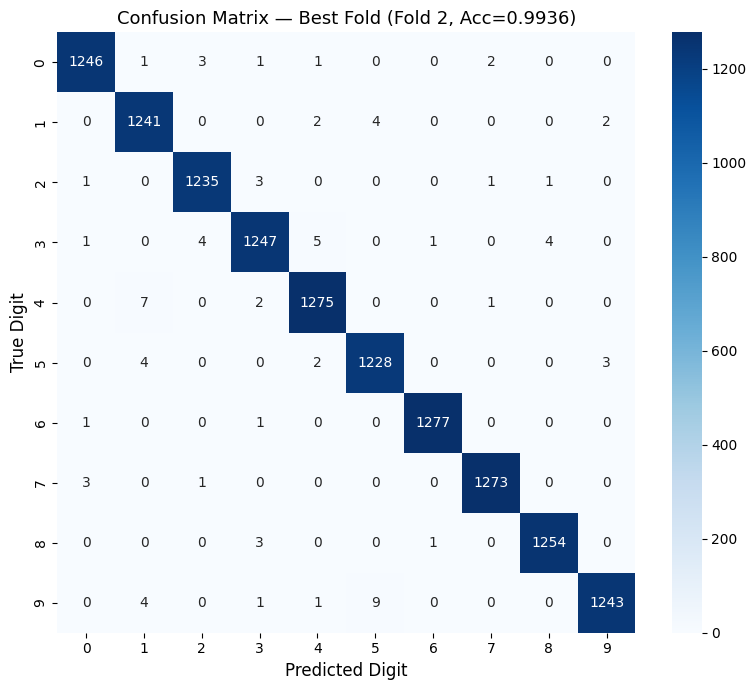

Final val accuracy (best fold): 0.9936


In [10]:
# ============================================================
# EVALUATION — Confusion Matrix on Last Fold's Validation Set
# ============================================================
# Load the best fold model and evaluate on the last validation split
best_fold_idx = np.argmax(fold_accuracies)
best_model    = AudioEfficientNet(num_classes=CFG['num_classes']).to(device)
best_model.load_state_dict(torch.load(fold_model_paths[best_fold_idx]))
best_model.eval()

# Get last fold's val split
splits = list(StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True,
                               random_state=SEED).split(train_df, train_df['label']))
_, val_idx_best = splits[best_fold_idx]
val_df_best = train_df.iloc[val_idx_best]

val_ds_eval = AudioDataset(val_df_best, CFG['train_path'], CFG,
                           is_train=False, has_labels=True)
val_loader_eval = DataLoader(val_ds_eval, batch_size=64, shuffle=False)

all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in val_loader_eval:
        with autocast():
            logits = best_model(x.to(device))
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_targets.extend(y.numpy())

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Digit', fontsize=12)
ax.set_ylabel('True Digit', fontsize=12)
ax.set_title(f'Confusion Matrix — Best Fold (Fold {best_fold_idx+1}, '
             f'Acc={fold_accuracies[best_fold_idx]:.4f})', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print(f"Final val accuracy (best fold): {accuracy_score(all_targets, all_preds):.4f}")

In [11]:
# ============================================================
# INFERENCE WITH TTA + MULTI-FOLD ENSEMBLE
# ============================================================
"""
Strategy:
  For each of the 3 fold models:
    For each of the 5 TTA augmentation variants:
      → Collect raw logits (NOT argmax)
  Average all 15 logit tensors → take argmax.

  This is a 15× ensemble. The baseline had a 3× ensemble but
  it was BROKEN (all 3 passes were the same). This properly
  averages predictions across diverse model checkpoints AND
  diverse augmentation variants.
"""

print("Starting TTA inference with multi-fold ensemble...")

# Accumulator for averaged logits across all folds × TTA passes
ensemble_logits = None
n_ensemble_passes = 0

for fold_idx, model_path in enumerate(fold_model_paths):
    # Load fold model
    fold_model = AudioEfficientNet(num_classes=CFG['num_classes']).to(device)
    fold_model.load_state_dict(torch.load(model_path))
    fold_model.eval()

    for shift in CFG['tta_shifts']:
        print(f"  Fold {fold_idx+1} | TTA shift={shift:+d}")

        # FIX: pass tta_shift= so the dataset actually applies the shift!
        test_ds = AudioDataset(
            test_df, CFG['test_path'], CFG,
            is_train=False,
            tta_shift=shift,      # ← THE BUG FIX
            has_labels=False
        )
        test_loader = DataLoader(
            test_ds, batch_size=CFG['batch_size'],
            shuffle=False, num_workers=CFG['num_workers']
        )

        pass_logits = []
        with torch.no_grad():
            for x in tqdm(test_loader, desc=f"    Predicting", leave=False):
                with autocast():
                    logits = fold_model(x.to(device))
                pass_logits.append(logits.cpu().float().numpy())

        pass_logits = np.vstack(pass_logits)  # (N_test, 10)

        if ensemble_logits is None:
            ensemble_logits = pass_logits
        else:
            ensemble_logits += pass_logits
        n_ensemble_passes += 1

# Average and take argmax
final_predictions = np.argmax(ensemble_logits / n_ensemble_passes, axis=1)

submission = pd.DataFrame({
    'id'   : test_df['id'],
    'label': final_predictions
})
submission.to_csv('submission.csv', index=False)

print(f"\n submission.csv generated ({n_ensemble_passes} ensemble passes)")
print(f"Label distribution in predictions:")
print(submission['label'].value_counts().sort_index())

Starting TTA inference with multi-fold ensemble...
  Fold 1 | TTA shift=+0


  Fold 1 | TTA shift=-800


  Fold 1 | TTA shift=+800


  Fold 1 | TTA shift=-1600


  Fold 1 | TTA shift=+1600


...

  Fold 3 | TTA shift=-800


  Fold 3 | TTA shift=+800


  Fold 3 | TTA shift=-1600


  Fold 3 | TTA shift=+1600



 submission.csv generated (15 ensemble passes)
   Label distribution in predictions:
label
0    1570
1    1682
2    1629
3    1585
4    1606
5    1639
6    1594
7    1625
8    1642
9    1628
Name: count, dtype: int64
